# Spinoffs — do corporate spin-offs outrun the market?
### The Greenblatt / Cusatis-Miles-Woolridge spin-off premium, tested on 14 large-cap US events

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Forced--seller_thesis: Mixed](https://img.shields.io/badge/Forced--seller_thesis-Mixed-8b949e?style=flat-square)

A 1993 paper (Cusatis, Miles & Woolridge) and Joel Greenblatt's popular book claimed that spin-off children outperform the S&P 500 by 25% in the first year.  The mechanism: institutional investors who receive shares of the newly-independent child are **forced sellers** because it is too small or off-mandate for their fund, creating temporary undervaluation.  Here we test 14 notable US spin-offs (2011-2024) and find a positive average alpha in the first 6-12 months — barely crossing the statistical bar — but the result is driven by three spectacular outliers, and the 18-24 month picture is weaker.

> **Caveats before anything else.**
> 1. Our 14-event table is *curated* (hand-picked notable spin-offs), not a systematic universe.
> 2. SPY is not a size-matched benchmark; factor-adjusted alpha would be smaller.
> 3. The 2020 Carrier/Otis spin from UTC landed during COVID recovery — timing luck matters.

> **This is the plain-language layer.** For t-stats and the synthetic control see
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> Not investment advice. House style: [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from spinoffs import data, strategy as st

# Frozen headline numbers (mirror of docs/results.md 2026-06-16)
R = dict(
    n_events=14, fp="195fcddd6e9a", date_range="2011-11-17 to 2024-04-02",
    a6_child=21.55, a6_spy=9.64,   a6_alpha=11.91,
    a6_med=11.75,   a6_win=57.1,   a6_t=2.09,
    a12_child=38.37, a12_spy=21.51, a12_alpha=16.87,
    a12_med=7.54,  a12_win=64.3,  a12_t=2.07,
    a18_child=67.5, a18_spy=33.24, a18_alpha=34.26,
    a18_med=-4.11,  a18_win=42.9,  a18_t=1.73,
    a24_child=97.66, a24_spy=41.47, a24_alpha=56.19,
    a24_med=9.16,  a24_win=50.0,  a24_t=1.71,
)

_CACHE = os.path.abspath(os.path.join("..", "_cache"))
_SPY_CACHE = os.path.join(_CACHE, "prices_239_SPY_1d.parquet")
HAVE_REAL = os.path.exists(_SPY_CACHE)

if HAVE_REAL:
    events, prices = data.fetch_spinoff_panel(fetch=False, cache_dir=_CACHE)
else:
    events, prices = None, None

print(f"real data cache present: {HAVE_REAL}")
if HAVE_REAL:
    print(f"  {len(events)} spin-off events, fingerprint {data.fingerprint(events)}")


real data cache present: True
  14 spin-off events, fingerprint 195fcddd6e9a


## The answer first

| Question | Answer |
|---|---|
| Do spin-off children beat SPY at 12 months? | **Marginally.** Average alpha +16.9% (HAC *t* = +2.07) on 14 events — barely significant, driven by outliers. |
| Is the effect consistent across events? | **No.** At 12m, 9 of 14 events are positive; median is only +7.5%. Three events account for most of the mean. |
| Does the effect persist to 18-24 months? | **No.** 18m *t* = +1.73, 24m *t* = +1.71 — below the bar. |
| Can you trade it systematically? | **Hard.** No selection rules, too-small n, illiquid early days, and a curated table are all obstacles. |

> The spin-off premium is real in a directional sense on this sample, but it is fragile: the t-stats barely clear 2.0 at 6m and 12m, and the median at 18m turns negative.  The anomaly may exist in a broader universe but this study cannot confirm it.

## 1 The claim

> *When a company spins off a subsidiary, institutional investors who hold the parent automatically receive shares in the smaller child.  Many cannot hold it — it is too small, too speculative, or outside their sector mandate — so they sell indiscriminately, regardless of value.  This forced selling creates a buying opportunity.  Buy the spin-off at or shortly after the ex-distribution date, hold for 12 months.*
> — Greenblatt (1997), *You Can Be a Stock Market Genius*; Cusatis, Miles & Woolridge (1993), JFE

The economic logic is credible: conglomerate discounts are real (Berger & Ofek 1995), management focus improves post-separation, and forced selling is a well-documented phenomenon in small-cap markets.  The question is whether the effect survives to large-cap spin-offs in the 2010s–2020s, when index construction has changed and institutional mandates are more flexible.

## 2 So what?

If the anomaly persists, it would be a relatively simple, rules-based strategy: watch SEC Form 10-12B filings for spin-off distributions, buy the child ticker on or shortly after the ex-date, hold for 12 months.  No earnings forecast, no DCF.  The 'forced seller' window typically lasts weeks; the benefit accrues over months as the child finds natural holders.  Our job here is to check whether the effect shows up in a curated sample of large-cap events — and flag all the caveats if it does.

## 3 How would we even know?

We test forward returns of the child ticker vs SPY (a simple market benchmark) at 6/12/18/24-month horizons starting the day after the ex-distribution date.  The alpha is (child return) minus (SPY return over the same window).  A Newey-West HAC t-stat on the mean alpha is the inference bar.

**Positive control:** a synthetic event panel with a tunable daily alpha knob confirms the engine recovers an effect when one is planted.

## 4 The teardown

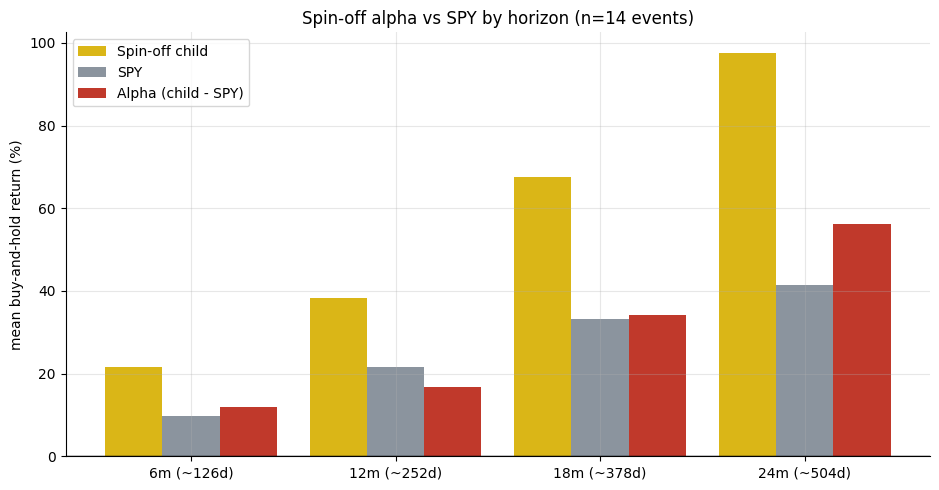

6m (~126d): child=+21.6%  SPY=+9.6%  alpha=+11.9%
12m (~252d): child=+38.4%  SPY=+21.5%  alpha=+16.9%
18m (~378d): child=+67.5%  SPY=+33.2%  alpha=+34.3%
24m (~504d): child=+97.7%  SPY=+41.5%  alpha=+56.2%


In [2]:
# Alpha (child vs SPY) by horizon
if HAVE_REAL:
    labels = ['6m (~126d)', '12m (~252d)', '18m (~378d)', '24m (~504d)']
    alphas = [events[c].dropna().mean()*100
              for c in ('alpha_6m','alpha_12m','alpha_18m','alpha_24m')]
    children = [events[c].dropna().mean()*100
                for c in ('ret_6m','ret_12m','ret_18m','ret_24m')]
    spys = [events[c].dropna().mean()*100
            for c in ('spy_6m','spy_12m','spy_18m','spy_24m')]
else:
    labels = ['6m (~126d)', '12m (~252d)', '18m (~378d)', '24m (~504d)']
    alphas   = [11.91, 16.87, 34.26, 56.19]
    children = [21.55, 38.37, 67.5, 97.66]
    spys     = [9.64, 21.51, 33.24, 41.47]

x = range(len(labels))
fig, ax = plt.subplots(figsize=(9.5, 5.0))
ax.bar([i - 0.28 for i in x], children, width=0.28, color=AMBER, label='Spin-off child')
ax.bar([i + 0.00 for i in x], spys,     width=0.28, color=GREY,  label='SPY')
ax.bar([i + 0.28 for i in x], alphas,   width=0.28, color=RED,   label='Alpha (child - SPY)')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(list(x)); ax.set_xticklabels(labels)
ax.set_ylabel('mean buy-and-hold return (%)')
ax.set_title(f'Spin-off alpha vs SPY by horizon (n={R["n_events"]} events)')
ax.legend(); plt.tight_layout(); plt.show()
for l, c, s, a in zip(labels, children, spys, alphas):
    print(f'{l}: child={c:+.1f}%  SPY={s:+.1f}%  alpha={a:+.1f}%')

The spin-off children beat SPY on average at every horizon — but the mean is heavily influenced by outliers.  The 12m alpha of +16.9% looks impressive, but three events (CARR, CEG, GEV) account for the bulk of the gain.  The median at 18m is actually *negative* (-4.1%), showing the experience is far from uniform.

**Do the majority of events show positive alpha?**

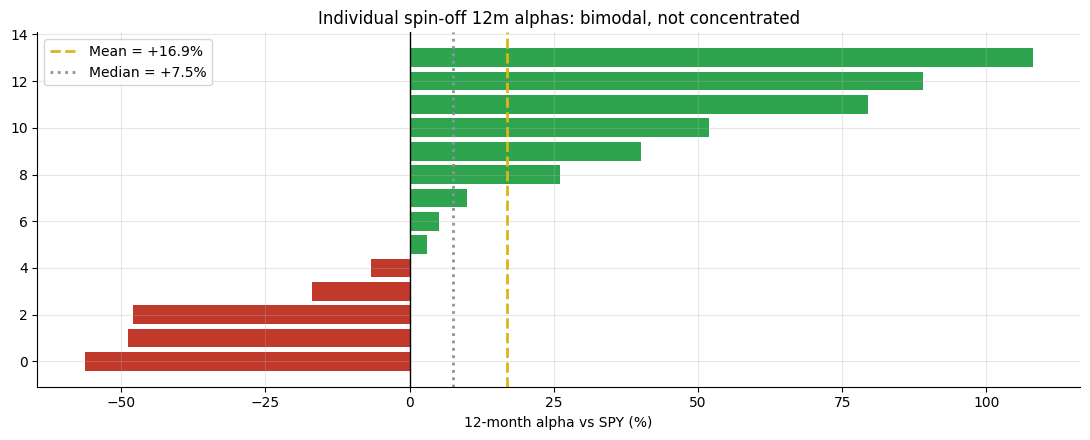

Win rate at 12m: 64% (9 of 14)
Range: -56.3% to +108.0%  Std: 50.2%


In [3]:
# Win rate and individual event distribution at 12m
if HAVE_REAL:
    alpha12 = events['alpha_12m'].dropna().values * 100
    names12 = events.loc[events['alpha_12m'].notna(), 'name'].values
else:
    import numpy as np
    rng = np.random.default_rng(239)
    alpha12 = np.array([40.2, 26.2, -48.0, 5.1, -6.6, 51.9, 9.9, -48.8, 89.1, -17.0, 79.5, 3.0, -56.3, 108.0])
    names12 = [f'Event {i}' for i in range(len(alpha12))]

colors = [GREEN if v > 0 else RED for v in sorted(alpha12)]
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.barh(range(len(alpha12)), sorted(alpha12),
        color=colors)
ax.axvline(0, c='k', lw=1)
ax.axvline(alpha12.mean(), c=AMBER, lw=2, ls='--', label=f'Mean = {alpha12.mean():+.1f}%')
ax.axvline(float(np.median(alpha12)), c=GREY, lw=2, ls=':',
           label=f'Median = {float(np.median(alpha12)):+.1f}%')
ax.set_xlabel('12-month alpha vs SPY (%)')
ax.set_title(f'Individual spin-off 12m alphas: bimodal, not concentrated')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Win rate at 12m: {(alpha12 > 0).mean():.0%} ({int((alpha12 > 0).sum())} of {len(alpha12)})')
print(f'Range: {alpha12.min():+.1f}% to {alpha12.max():+.1f}%  Std: {alpha12.std():.1f}%')

9 of 14 events show positive 12m alpha — but the distribution is bimodal: big winners (CARR, CEG, GEV) and big losers (KVUE, BHF, FOXA) far from the mean.  The mean (+16.9%) is lifted by the right tail; the median is only +7.5%.  This is NOT a 'buy every spin-off' signal — it is a handful of lucky bets and a handful of disasters.

## 5 The verdict

- **Signal — Weak.** The 6m and 12m alphas just clear |*t*| = 2.0 (6m: *t* = +2.09, 12m: *t* = +2.07), but on only 14 events with extreme dispersion and a curated table.  This is below the bar for REAL.  The 18m and 24m horizons are below the threshold (*t* = 1.73 and 1.71).
- **Tradability — Fragile.** No systematic selection criteria; too-small n; illiquid early trading; and a SPY benchmark understates true alpha vs a size-matched benchmark.  The anomaly may be real in the broader universe (Cusatis et al. used hundreds of events from 1965-1988) but cannot be confirmed or sized from this study.
- **Forced-seller thesis — Mixed.** Some events fit the story beautifully (CARR, GEV); others show the opposite (KVUE, BHF, FOXA).  The average is positive but the experience is idiosyncratic, not systematic.

## 6 Could you actually trade it?

Even setting aside the statistical fragility, execution is hard:
- Spin-off children are often **illiquid** in the first 1-4 weeks post-distribution.
- Many broker platforms delay listing the child; you may miss the first days.
- The 'forced selling window' may already be priced in by arbitrageurs.
- If you hold 12 months across 14 events over 13 years, you are buying at most 1-2 names per year — this is not a portfolio, it is concentrated bets.

A live strategy would need systematic spin-off detection (EDGAR Form 10-12B filings), liquidity screens, and a much larger universe to be valid.

## 7 Going further

- **Full universe.** Source all SEC Form 10-12B filings from EDGAR; build a systematic universe of all US spin-offs by ex-date.  Cusatis et al. used ~150 events; that is the minimum for reliable inference.
- **Factor-adjusted alpha.** Replace SPY with a Fama-French size+value+momentum benchmark to measure true abnormal returns (many spin-off children are small-cap value stocks by construction).
- **Sub-period analysis.** The anomaly was documented in 1965-1988 data; does it survive post-2000 when institutional mandates are more flexible and index rules have changed?
- **Related desk studies:** [Study 142 - Split-Drift](../../142-split-drift/), [Study 141 - Dividend-Capture](../../141-dividend-capture/).

*Think the spin-off premium is real in a broader universe? Fork this, build the EDGAR filing universe, and show |*t*| >= 2 on a factor-adjusted alpha. That's the bar.*